# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [19]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
# ── Load image ────────────────────────────────────
img = Image.open('cameraman.jpg').convert('L')
arr = np.array(img, dtype=float)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
width, height = img.size

# scaling factors
scale_x, scale_y = 2, 2
new_width = int(width * scale_x)
new_height = int(height * scale_y)


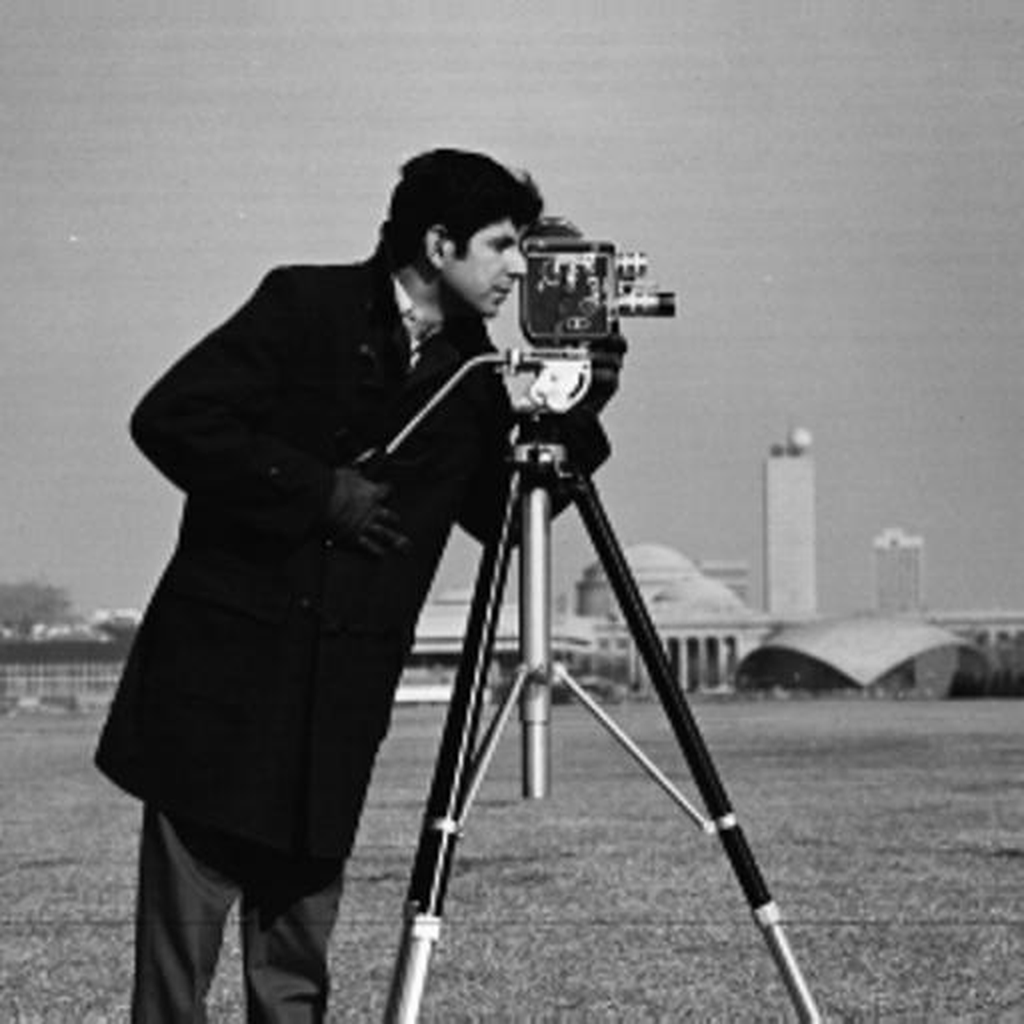

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_img = img.resize((new_width, new_height), Image.LANCZOS)
scaled_img


In [5]:
# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")
print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
# Non-uniform scaling (cx=2, cy=1)
new_width2 = int(width * 2)
new_height2 = int(height * 1)

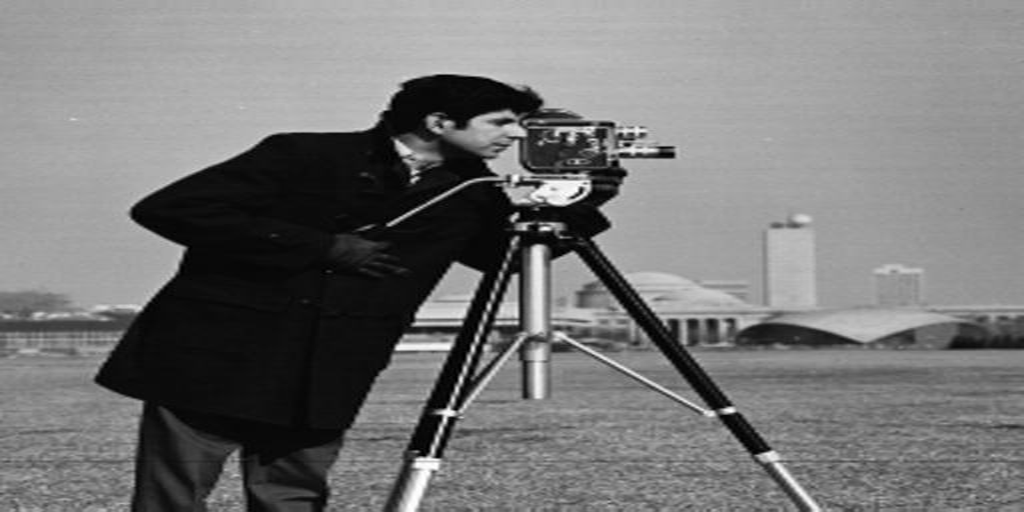

In [7]:
stretched_img = img.resize((new_width2, new_height2), Image.LANCZOS)
stretched_img

In [8]:
stretched_img.save("task1_1_nonuniform.jpg")
print("Stretched size:", stretched_img.size)

Stretched size: (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size: (700, 700)


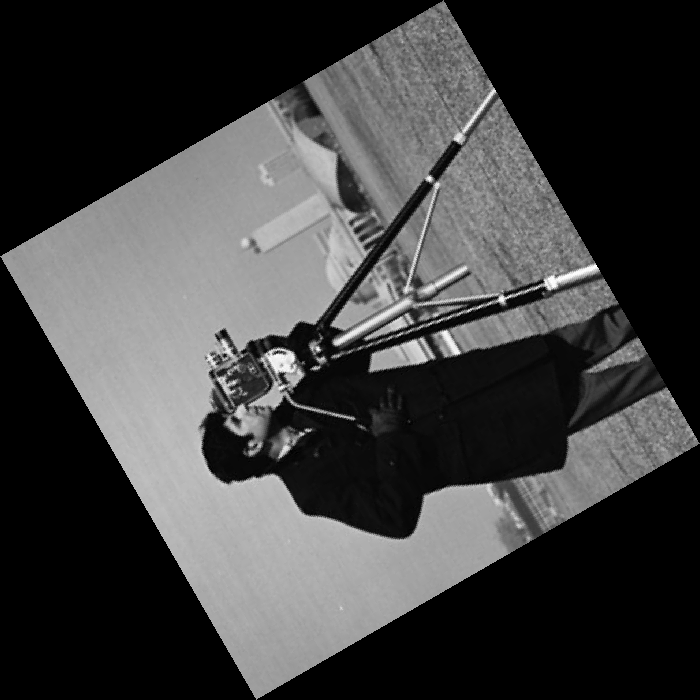

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotated_img = img.rotate(120, expand=True)
rotated_img.save("task1_2_rotated.jpg")

print("Original size:", img.size)
print("Rotated size:", rotated_img.size)
rotated_img

### 3. Shear

In [10]:
# -- c. Get the image dimensions ────────────────────
w, h = img.size

In [11]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.

shear_factor = 0.5

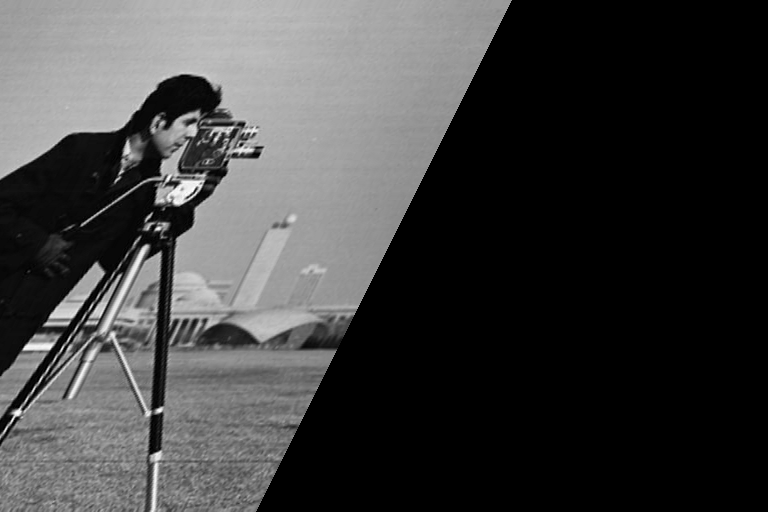

In [12]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

sheared_img = img.transform(
    (int(w + shear_factor * h), h),
    Image.AFFINE,
    (1, shear_factor, 0, 0, 1, 0),
    Image.BICUBIC
)

sheared_img

In [13]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 

sheared_img.save("task1_3_sheared.jpg")

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

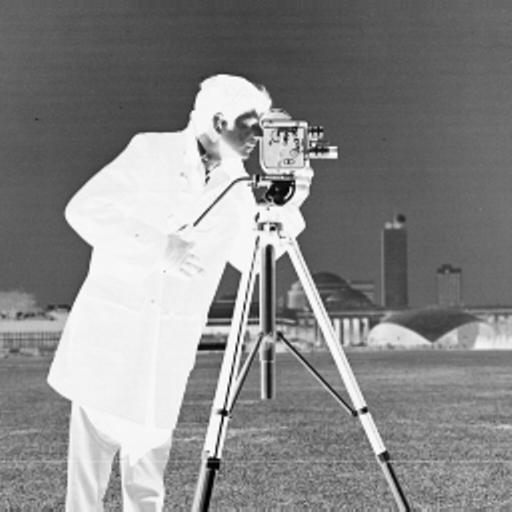

In [14]:
# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation

img_np = np.array(img)
negative_np = 255 - img_np
negative_img = Image.fromarray(negative_np.astype(np.uint8))

negative_img.save("task2_negative_numpy.jpg")
negative_img

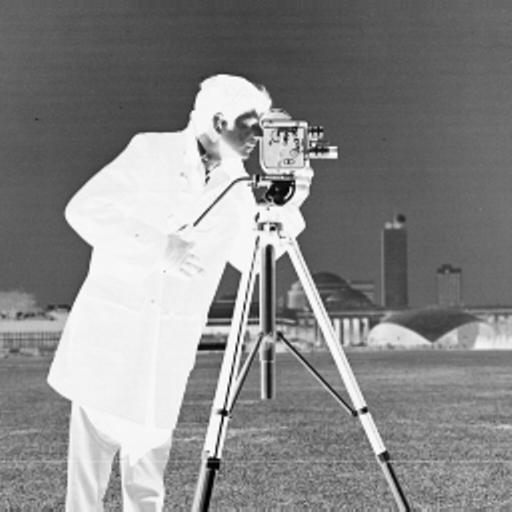

In [17]:
# Method 2: PIL's ImageOps

negative_pil = ImageOps.invert(img)
negative_pil.save("task2_negative_pil.jpg")
negative_pil

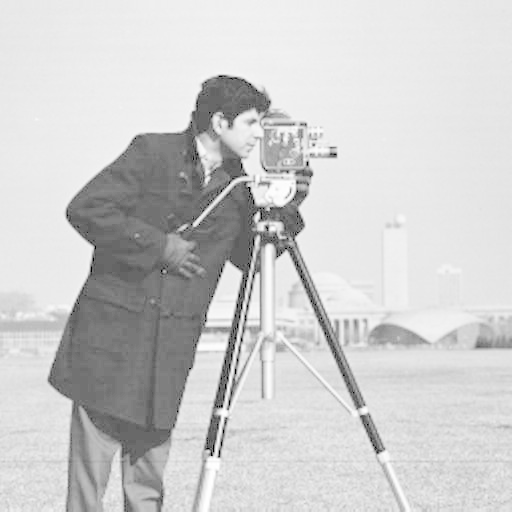

In [20]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)

c = 255 / math.log(1 + 255)

img_np = np.array(img, dtype=np.float32)
log_transformed = c * np.log(1 + img_np)

log_img = Image.fromarray(np.uint8(log_transformed))
log_img.save("task2_log.jpg")
log_img

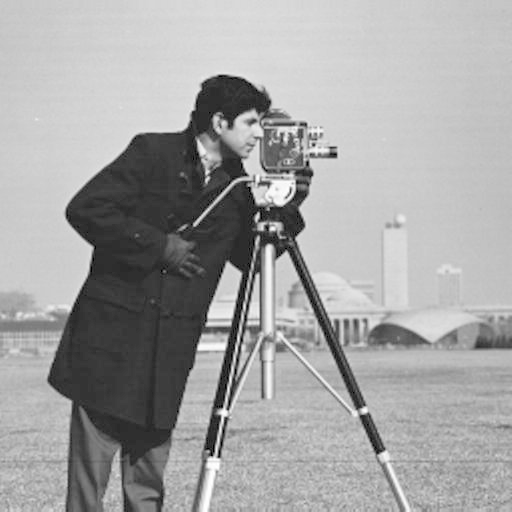

In [21]:
# ── 3. Power-law / Gamma correction ───────────────

gamma = 0.5  # try different values like 0.3, 1.5, 2.0

img_np = np.array(img, dtype=np.float32) / 255.0
gamma_corrected = np.power(img_np, gamma) * 255

gamma_img = Image.fromarray(np.uint8(gamma_corrected))
gamma_img.save("task2_gamma.jpg")
gamma_img

In [22]:
print("All transformations completed and images saved successfully.")

All transformations completed and images saved successfully.
